# Interpretability Analysis of ResNet18 Using CAM

### Model choice

I chose ResNet18 with pretrained ImageNet weights for this assignment. A main reason was limited hardware, since ResNet18 is smaller and more efficient than many larger CNN models. This made it more suitable for running repeated experiments on several images and layers.

At the same time, ResNet18 is a well-established image classification model that still performs strongly. Since it is pretrained on ImageNet, it is a good choice for analyzing how a CNN responds to different image classes using CAM-based interpretability methods.

Overall, ResNet18 was chosen because it offers a practical balance between computational efficiency, classification performance, and interpretability.


In [1]:
from pathlib import Path
import json
import pandas as pd
import torch
import sys
from torchvision.models import get_model, get_model_weights

root = Path("..").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions import (
    create_image_sources,
    add_image_sources,
    save_image_sources,
    run_analysis_pipeline,
    top_k_predictions,
    top_k_logits
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = DATA_DIR / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CLASS_INDEX_PATH = DATA_DIR / "imagenet_class_index.json"

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).to(DEVICE).eval()
preprocess = weights.transforms()


### Checking if the selected object exists in the imagenet.

In [2]:
with open(CLASS_INDEX_PATH, "r", encoding="utf-8") as f:
    imagenet_classes = json.load(f)

def search_classes(keyword):
    keyword = keyword.lower()
    matches = []

    for idx, (synset, class_name) in imagenet_classes.items():
        if keyword in class_name.lower():
            matches.append((int(idx), synset, class_name))

    return sorted(matches, key=lambda x: x[0])

display(search_classes("zebra"))
display(search_classes("school_bus"))
display(search_classes("cellular_telephone"))
display(search_classes("donkey"))
display(search_classes("tiger"))
display(search_classes("horse"))
display(search_classes("pokémon"))

[(340, 'n02391049', 'zebra')]

[(779, 'n04146614', 'school_bus')]

[(487, 'n02992529', 'cellular_telephone')]

[]

[(3, 'n01491361', 'tiger_shark'),
 (282, 'n02123159', 'tiger_cat'),
 (292, 'n02129604', 'tiger'),
 (300, 'n02165105', 'tiger_beetle')]

[(603, 'n03538406', 'horse_cart')]

[]

---

In [3]:
image_sources = create_image_sources()

image_sources = add_image_sources(
    image_sources,
    filename="zebra_pos_1.jpg",
    class_target="zebra",
    role="positive",
    image_description="zebra standing in grass field in profile",
    source_url="https://www.pexels.com/photo/zebra-in-grass-field-7558214/",
    source_site="Pexels",
    license="",
    notes="main positive example"
)

image_sources = add_image_sources(
    image_sources,
    filename="zebra_neg_1.jpg",
    class_target="zebra",
    role="negative",
    image_description="donkey standing in grass field in profile",
    source_url="https://www.pexels.com/photo/donkey-standing-on-grassy-lawn-9542225/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="zebra_neg_2.jpg",
    class_target="zebra",
    role="negative",
    image_description="Tiger with black and white stripes in profile.",
    source_url="https://www.pexels.com/photo/majestic-white-tiger-striding-in-lush-greenery-31447782/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="zebra_neg_3.jpg",
    class_target="zebra",
    role="negative",
    image_description="Horse in field",
    source_url="https://www.pexels.com/photo/a-horse-on-the-grass-15008068/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="school_bus_pos_1.jpg",
    class_target="school_bus",
    role="positive",
    image_description="Yellow school bus in slight profile",
    source_url="https://www.pexels.com/photo/yellow-school-bus-19760978/",
    source_site="Pexels",
    license="",
    notes="main positive example"
)

image_sources = add_image_sources(
    image_sources,
    filename="school_bus_neg_1.jpg",
    class_target="school_bus",
    role="negative",
    image_description="Rusty normal bus in profile",
    source_url="https://www.pexels.com/photo/colorful-indian-bus-on-rainy-urban-street-33332023/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="school_bus_neg_2.jpg",
    class_target="school_bus",
    role="negative",
    image_description="Yellow car in profile",
    source_url="https://www.pexels.com/photo/classic-chevrolet-chevette-in-garage-18325796/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="cellular_telephone_pos_1.jpg",
    class_target="cellular_telephone",
    role="positive",
    image_description="Nokia 3310",
    source_url="https://www.pexels.com/photo/a-nokia-3310-cellular-phone-19335258/",
    source_site="Pexels",
    license="",
    notes="positive example"
)

image_sources = add_image_sources(
    image_sources,
    filename="cellular_telephone_neg_1.jpg",
    class_target="cellular_telephone",
    role="negative",
    image_description="Remote control for AC",
    source_url="https://www.pexels.com/photo/remote-control-of-air-conditioner-25525671/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="cellular_telephone_neg_2.jpg",
    class_target="cellular_telephone",
    role="negative",
    image_description="drone controller",
    source_url="https://www.pexels.com/photo/drone-controller-3861803/",
    source_site="Pexels",
    license="",
    notes="negative example"
)

image_sources = add_image_sources(
    image_sources,
    filename="pikachu_pos_1.jpg",
    class_target="pikachu",
    role="ood",
    image_description="Pikachu plush toy",
    source_url="https://www.pexels.com/photo/cute-pikachu-plush-toy-on-rock-outdoors-36495537/",
    source_site="Pexels",
    license="",
    notes="positive example"
)

save_image_sources(image_sources, DATA_DIR / "image_sources.csv")
print("Saved 'image_sources.csv'")

image_sources

Saved 'image_sources.csv'


,filename,class_target,role,image_description,source_url,source_site,license,notes
0,zebra_pos_1.jpg,zebra,positive,zebra standing in grass field in profile,https://www.pexels.com/photo/zebra-in-grass-fi...,Pexels,,main positive example
1,zebra_neg_1.jpg,zebra,negative,donkey standing in grass field in profile,https://www.pexels.com/photo/donkey-standing-o...,Pexels,,negative example
2,zebra_neg_2.jpg,zebra,negative,Tiger with black and white stripes in profile.,https://www.pexels.com/photo/majestic-white-ti...,Pexels,,negative example
3,zebra_neg_3.jpg,zebra,negative,Horse in field,https://www.pexels.com/photo/a-horse-on-the-gr...,Pexels,,negative example
4,school_bus_pos_1.jpg,school_bus,positive,Yellow school bus in slight profile,https://www.pexels.com/photo/yellow-school-bus...,Pexels,,main positive example
5,school_bus_neg_1.jpg,school_bus,negative,Rusty normal bus in profile,https://www.pexels.com/photo/colorful-indian-b...,Pexels,,negative example
6,school_bus_neg_2.jpg,school_bus,negative,Yellow car in profile,https://www.pexels.com/photo/classic-chevrolet...,Pexels,,negative example
7,cellular_telephone_pos_1.jpg,cellular_telephone,positive,Nokia 3310,https://www.pexels.com/photo/a-nokia-3310-cell...,Pexels,,positive example
8,cellular_telephone_neg_1.jpg,cellular_telephone,negative,Remote control for AC,https://www.pexels.com/photo/remote-control-of...,Pexels,,negative example
9,cellular_telephone_neg_2.jpg,cellular_telephone,negative,drone controller,https://www.pexels.com/photo/drone-controller-...,Pexels,,negative example


___

### Zebra analysis

Predicted class: zebra
Confidence: 0.9997296929359436
Target layer: default


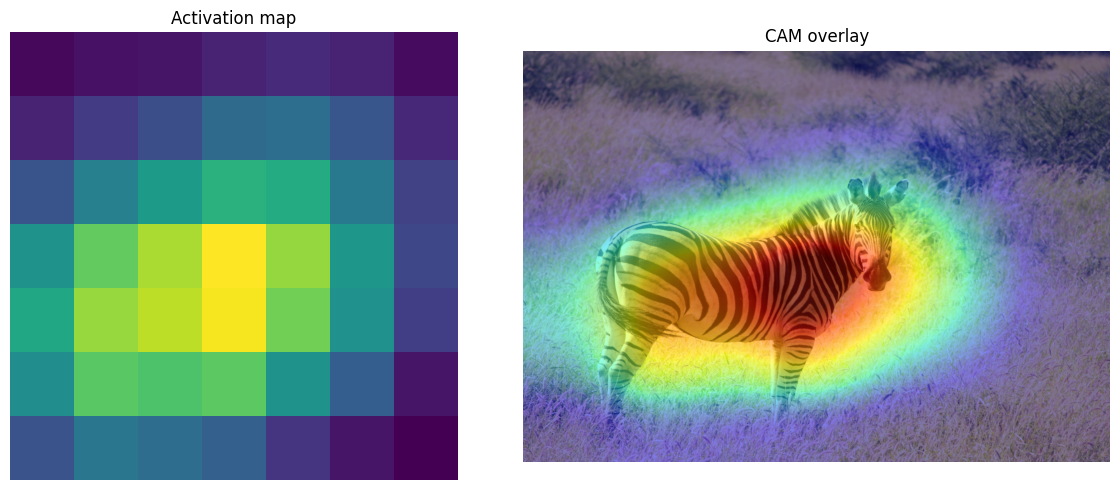

In [4]:
zebra_pos_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "positives" / "zebra_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: water_buffalo
Confidence: 0.5373364090919495
Target layer: default


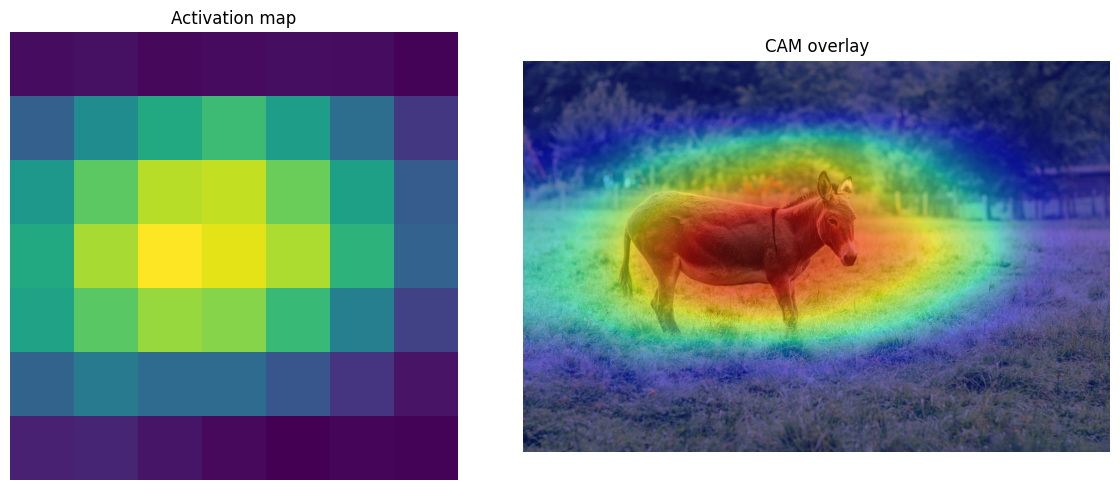

In [5]:
zebra_neg_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "zebra_neg_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: tiger
Confidence: 0.7505024671554565
Target layer: default


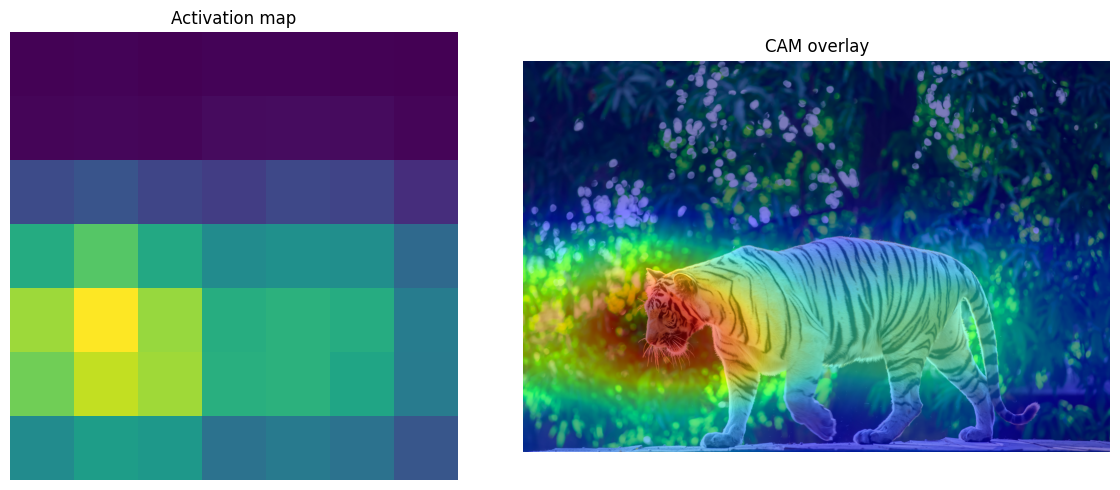

In [6]:
zebra_neg_2_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "zebra_neg_2.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: ram
Confidence: 0.41471385955810547
Target layer: default


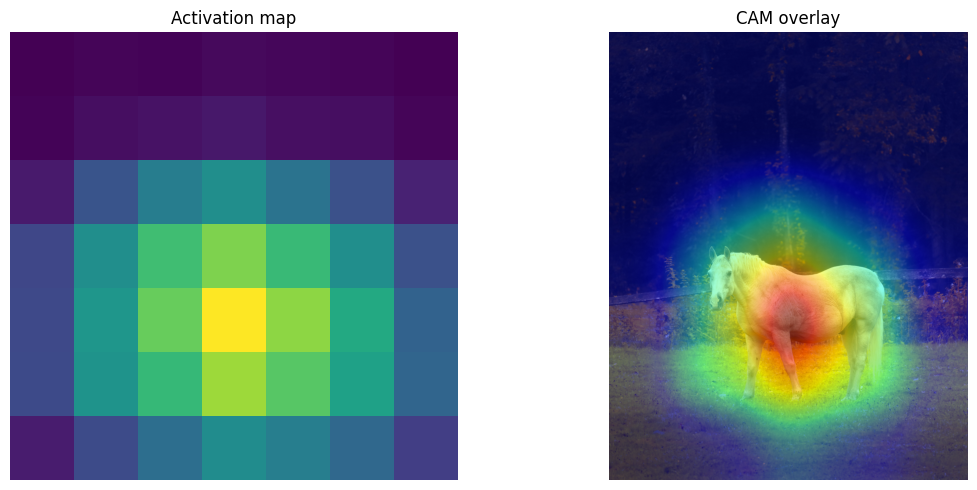

In [7]:
zebra_neg_3_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "zebra_neg_3.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

#### Results

zebra_pos_1.jpg was correctly classified as zebra with very high confidence (99.97%). The activation map appears to focus mainly on the front half of the body rather than the background, which suggests that the model is using features from the animal itself and not from the surrounding grass field.

The first negative example, the donkey, was classified as water_buffalo with a confidence of 53.7%. Since the donkey has a somewhat similar body shape to a zebra but lacks the zebra stripe pattern, this suggests that body shape alone is not sufficient for the model to predict zebra.

The second negative example, the white tiger, was classified as tiger with 75.0% confidence. This is interesting because the tiger shares some visual similarity with the zebra through its striped texture. However, the model still predicted tiger, and the activation map focused strongly on the face. This suggests that stripe-like texture alone is not enough for a zebra prediction; the overall animal structure and class-specific features also matter.

The third negative example, the horse, was classified as ram with a lower confidence of 41.5%. Compared with the other examples, this lower confidence suggests that the model was more uncertain. The activation map seems to focus more on the body than on the head, which may indicate that the model is using broader shape-related features but failing to find a strong class match.


---

### School bus analysis

Predicted class: school_bus
Confidence: 0.9999308586120605
Target layer: default


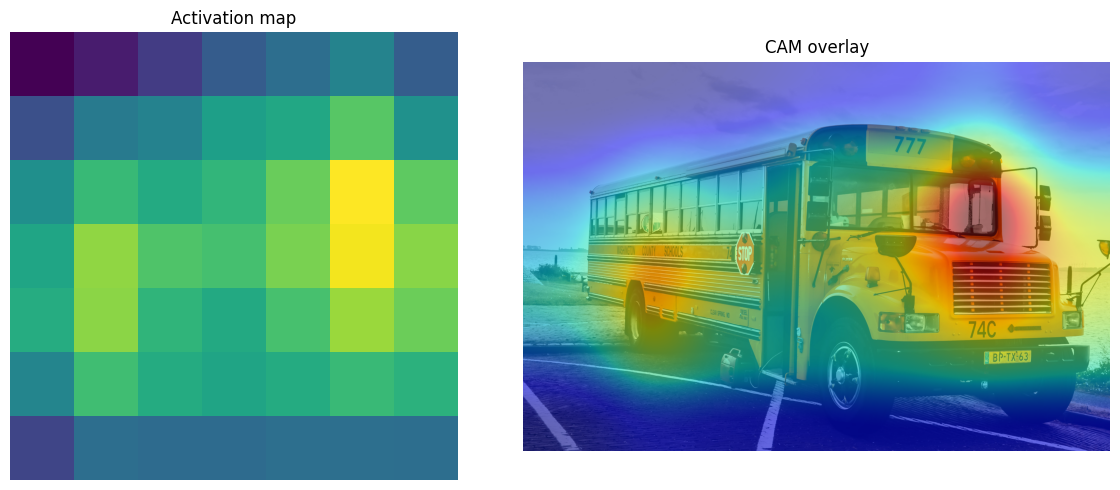

In [8]:
school_bus_pos_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "positives" / "school_bus_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: minibus
Confidence: 0.7018153667449951
Target layer: default


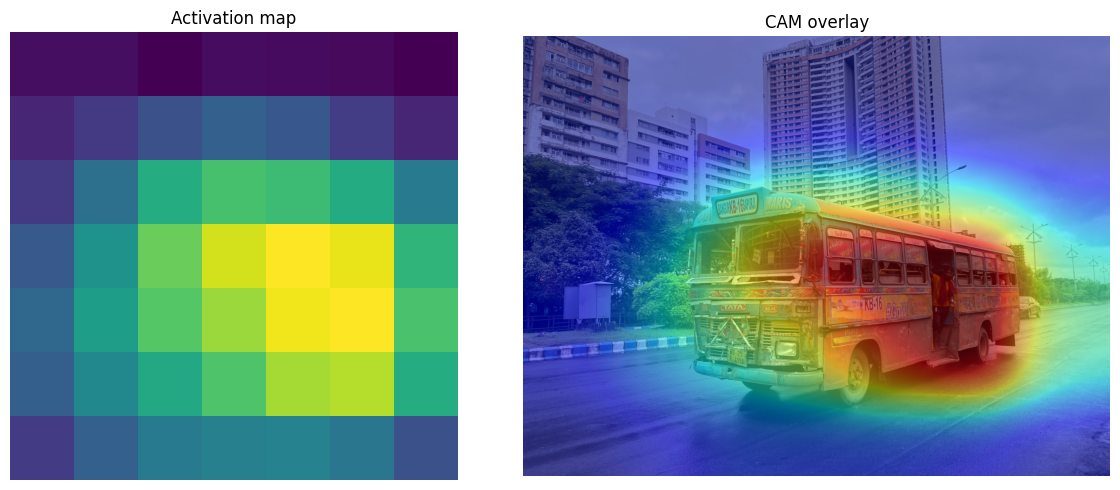

In [9]:
school_bus_neg_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "school_bus_neg_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: cab
Confidence: 0.900536298751831
Target layer: default


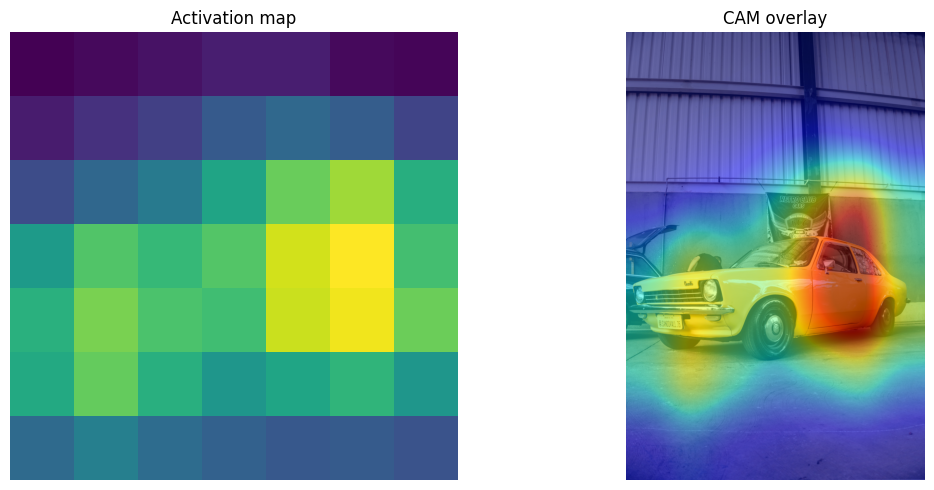

In [10]:
school_bus_neg_2_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "school_bus_neg_2.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

#### Results

school_bus_pos_1.jpg was correctly classified as school_bus with very high confidence (99.99%). The activation map appears to focus strongly on the main body of the bus rather than the surroundings, which suggests that the model is using the object shape and visual structure of the vehicle itself.

The first negative example, a normal bus, was classified as minibus with 70.18% confidence. This is interesting because the vehicle still shares the overall bus-like shape with a school bus, but the model did not classify it as school_bus. This suggests that the general vehicle form alone is not enough; more specific visual features are needed. Also, how important is the actual color?

The second negative example, a yellow car, was classified as cab with 90.05% confidence. Since this image shares the yellow color with a school bus but not the same larger structure, the result suggests that color alone is also not enough for a school_bus prediction. The model seems to rely on a combination of shape, size, and class-specific vehicle features.


---

### Cellular telephone analysis

Predicted class: cellular_telephone
Confidence: 0.9502188563346863
Target layer: default


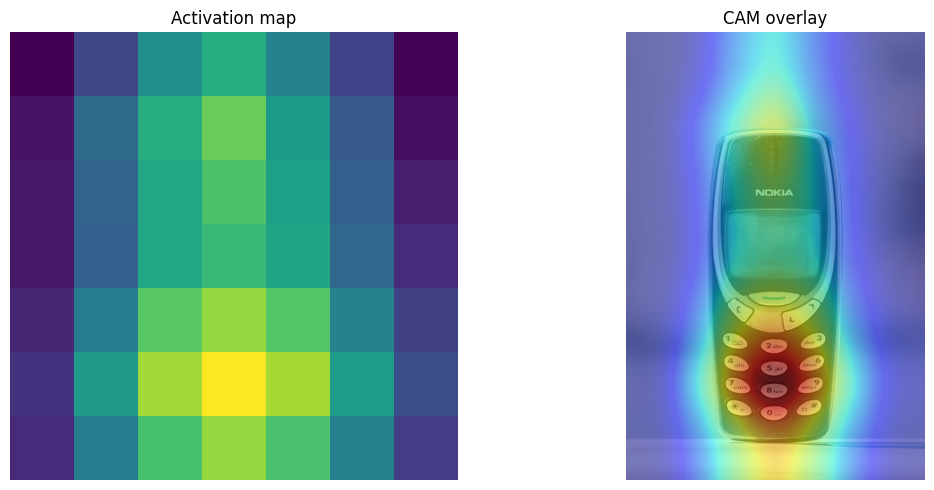

In [11]:
cellular_telephone_pos_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "positives" / "cellular_telephone_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: remote_control
Confidence: 0.565459132194519
Target layer: default


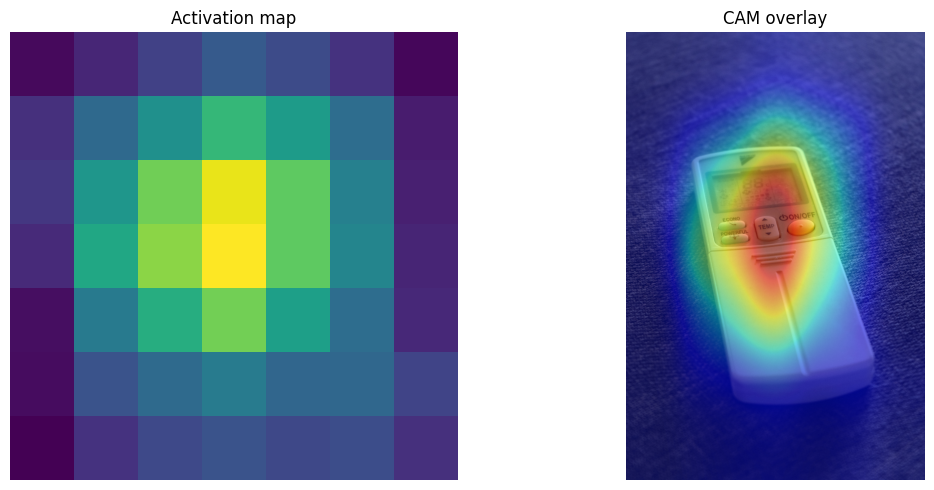

In [12]:
cellular_telephone_neg_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "cellular_telephone_neg_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

Predicted class: joystick
Confidence: 0.8927523493766785
Target layer: default


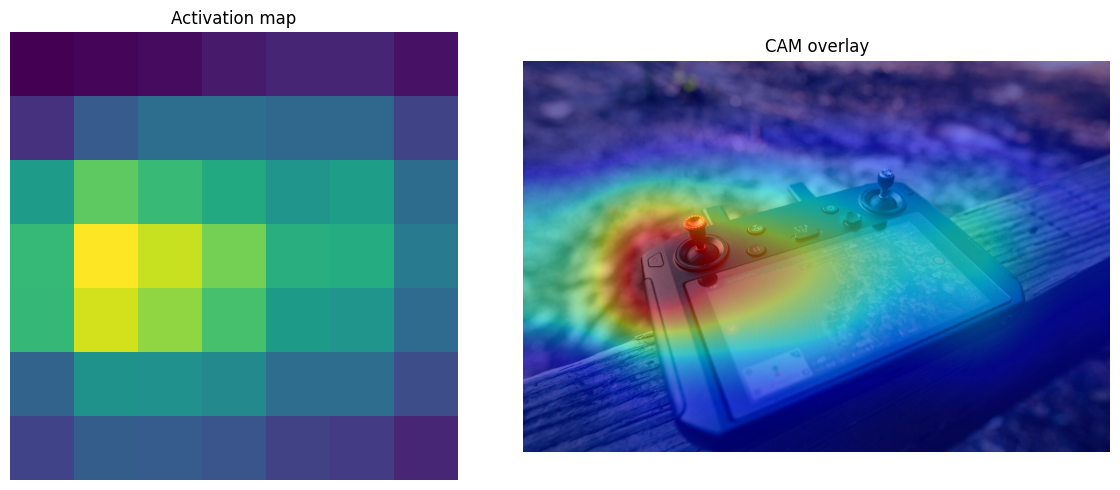

In [13]:
cellular_telephone_neg_2_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "negatives" / "cellular_telephone_neg_2.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

#### Results

cellular_telephone_pos_1.jpg was correctly classified as cellular_telephone with a confidence of 95.02%. The activation map appears to focus on the central parts of the phone body, which suggests that the model is using the overall structure of the device rather than the background.

The first negative example, the air conditioner remote control, was classified as remote_control with 56.55% confidence. This is interesting because the object shares several visual features with a mobile phone, such as a narrow rectangular shape and buttons. The fact that it was not classified as cellular_telephone suggests that the model can distinguish between similar hand-held electronic devices.

The second negative example, the drone controller, was classified as joystick with 89.28% confidence. Compared with the remote control, this example has a stronger association with control hardware, and the model seems much more confident in its prediction. This suggests that the model relies not only on the size and shape of the object, but also on more specific structural features such as handles, control layout, and device design.


---

### OOD analysis

Predicted class: piggy_bank
Confidence: 0.24837440252304077
Target layer: default


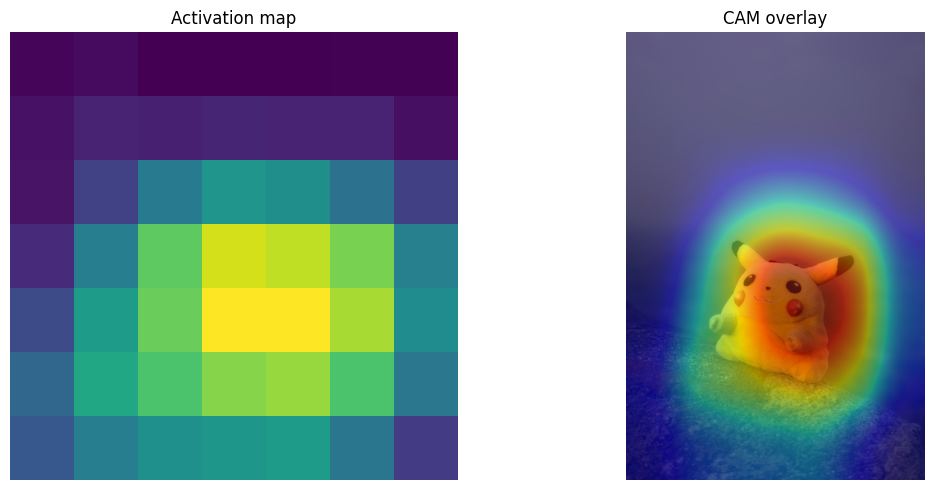

In [14]:
pikachu_pos_1_result = run_analysis_pipeline(
    image_path = IMAGE_DIR / "ood" / "pikachu_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH
)

#### Results

The OOD image pikachu_pos_1.jpg was classified as piggy_bank with a relatively low confidence of 24.84%. Since Pikachu is not a class in the pretrained ImageNet labels, the model is forced to map the image to the closest class it knows. The low confidence suggests that the model is uncertain about this prediction.

The activation map still highlights the main body of the object, which indicates that the model is focusing on Pikachu itself rather than the background. A possible explanation for the piggy_bank prediction is that the rounded yellow body and toy-like appearance resemble a small artificial object more than a real animal. The body shape might be relatively close to the body shape of a general piggy bank.


---

### top-k analysis

In [15]:
top_k_predictions(zebra_neg_2_result["prediction"], CLASS_INDEX_PATH, k=5)

,class_index,class_id,class_name,confidence
0,292,n02129604,tiger,0.750502
1,282,n02123159,tiger_cat,0.241290
2,340,n02391049,zebra,0.005811
3,281,n02123045,tabby,0.001159
4,285,n02124075,Egyptian_cat,0.000196


In [16]:
top_k_predictions(zebra_pos_result["prediction"], CLASS_INDEX_PATH, k=5)


,class_index,class_id,class_name,confidence
0,340,n02391049,zebra,0.999730
1,282,n02123159,tiger_cat,0.000141
2,292,n02129604,tiger,0.000061
3,293,n02130308,cheetah,0.000017
4,281,n02123045,tabby,0.000011


#### Results

For zebra_neg_2.jpg, the model predicted tiger with a confidence of 75.05%, while tiger_cat was the second most likely class at 24.13%. zebra was still present in the top-5 predictions, but only with a confidence of about 0.58%. This suggests that the model detected some zebra-like visual features, but that tiger-related features were much stronger overall.

For zebra_pos_1.jpg, zebra was by far the most likely class with a confidence of 99.97%. Although tiger also appeared in the top-5 predictions, its confidence was extremely low. This indicates that striped animal classes may share some visual features, but that the true zebra image contains much stronger class-specific evidence.


___

#### Logit analysis

In [17]:
top_k_logits(zebra_neg_2_result["output"], CLASS_INDEX_PATH, k=5)


,class_index,class_id,class_name,logit
0,292,n02129604,tiger,15.849220
1,282,n02123159,tiger_cat,14.714478
2,340,n02391049,zebra,10.988223
3,281,n02123045,tabby,9.376163
4,285,n02124075,Egyptian_cat,7.596946


In [18]:
top_k_logits(zebra_pos_result["output"], CLASS_INDEX_PATH, k=5)


,class_index,class_id,class_name,logit
0,340,n02391049,zebra,21.136003
1,282,n02123159,tiger_cat,12.268803
2,292,n02129604,tiger,11.426794
3,293,n02130308,cheetah,10.163680
4,281,n02123045,tabby,9.700114


#### Results

The logit analysis shows that zebra and tiger share some visually relevant features, since both classes appear among the highest-ranked outputs in the two examples. For zebra_neg_2.jpg, the model clearly favored tiger (15.85) and tiger_cat (14.71) over zebra (10.99). This suggests that although the model detected some zebra-like features, tiger-related features were much stronger overall.

For zebra_pos_1.jpg, zebra had the highest logit by a large margin (21.14), while tiger_cat (12.27) and tiger (11.43) were much lower. This indicates that the real zebra image contains much stronger zebra-specific evidence, even though other striped-animal classes still share some visual similarity.

Overall, the logit analysis suggests that the model does not rely on stripe pattern alone. Instead, it seems to combine texture with broader class-specific features when separating zebra from tiger-related classes.


### Layer analysis

#### zebra

Predicted class: zebra
Confidence: 0.9997296929359436
Target layer: layer1


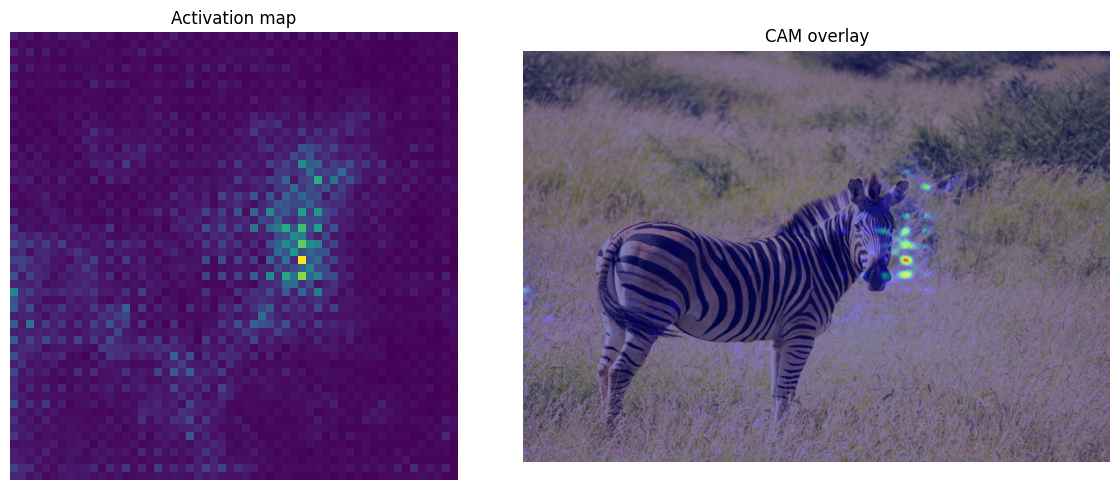

In [19]:
zebra_layer1 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "zebra_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer1"
)

Predicted class: zebra
Confidence: 0.9997296929359436
Target layer: layer2


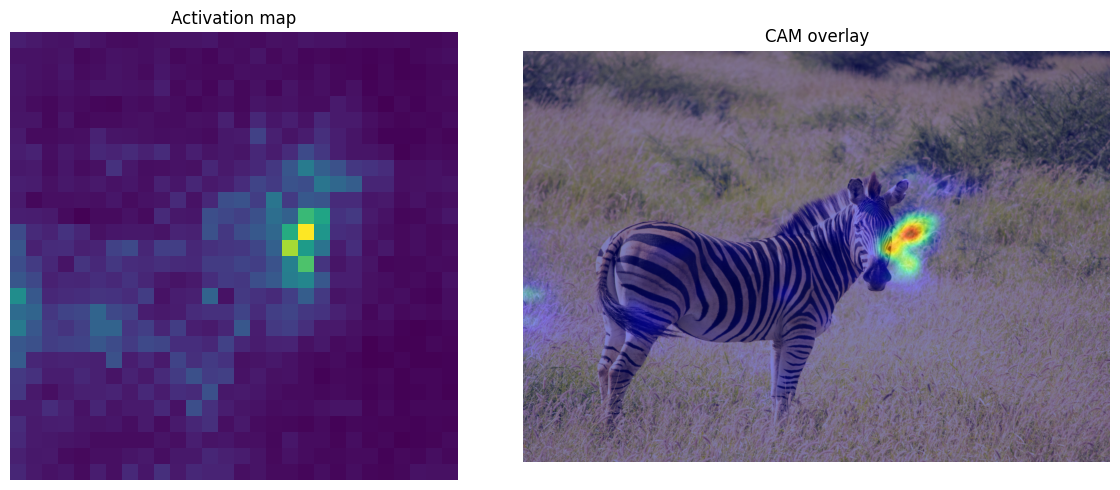

In [20]:
zebra_layer2 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "zebra_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer2"
)

Predicted class: zebra
Confidence: 0.9997296929359436
Target layer: layer4


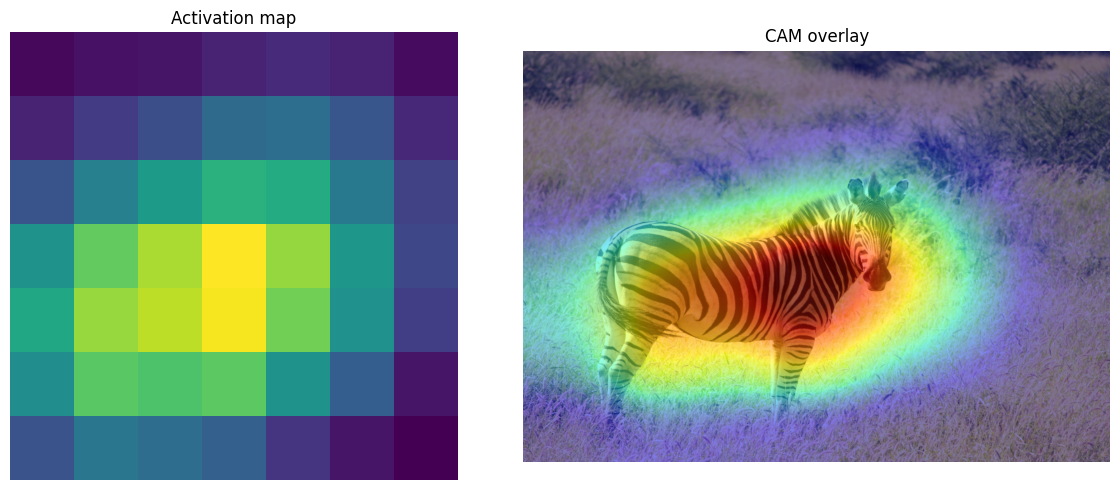

In [21]:
zebra_layer4 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "zebra_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer4"
)

#### Results

For the zebra image, the predicted class stayed the same across all three layers, and the confidence was unchanged. The main difference was instead how the activation map was distributed across the object.

In layer1, the activation map appears more spread out and less selective. The model seems to respond to simpler visual features such as edges, contrast, and stripe-like texture across a larger part of the image, with most activation on the right side of its head.

In layer2, the activation becomes more concentrated on larger regions of the zebra. Compared with layer1, the map appears less noisy and more object-centered, suggesting that the model is starting to combine low-level features into more meaningful animal parts.

In layer4, the activation map appears more focused on the most class-relevant parts of the zebra. This suggests that the later layer is using more abstract and class-specific features, rather than only local texture or edges.

Overall, the comparison suggests that earlier layers capture more general visual patterns, while later layers focus more strongly on the object regions that are most important for predicting the zebra class.


#### School bus

Predicted class: school_bus
Confidence: 0.9999308586120605
Target layer: layer1


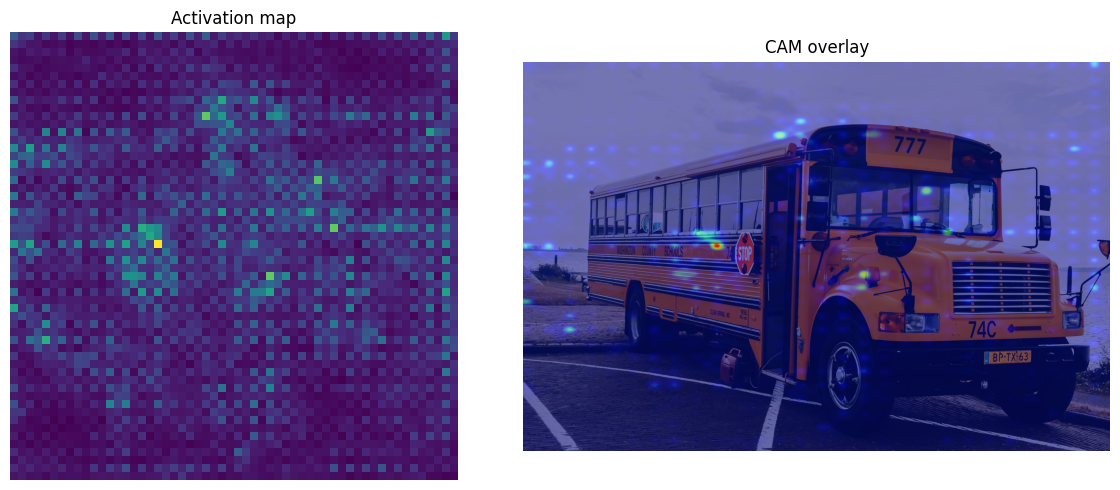

In [22]:
school_bus_layer1 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "school_bus_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer1"
)

Predicted class: school_bus
Confidence: 0.9999308586120605
Target layer: layer2


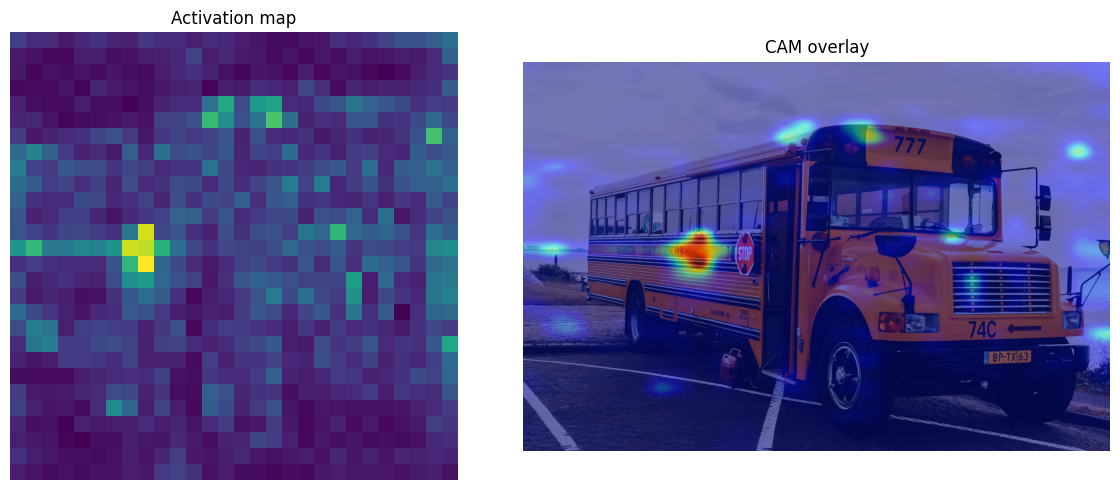

In [23]:
school_bus_layer2 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "school_bus_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer2"
)

Predicted class: school_bus
Confidence: 0.9999308586120605
Target layer: layer4


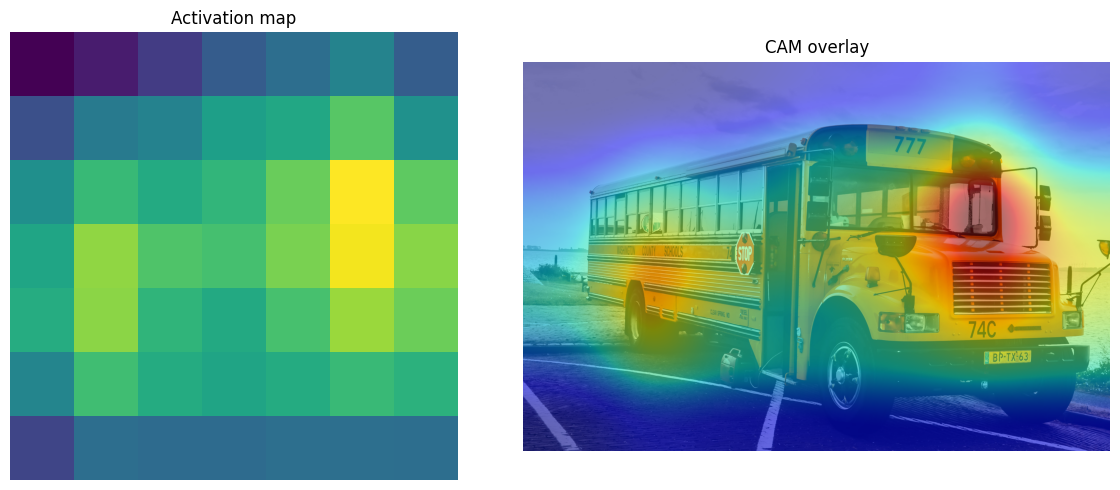

In [24]:
school_bus_layer4 = run_analysis_pipeline(
    image_path=IMAGE_DIR / "positives" / "school_bus_pos_1.jpg",
    model=model,
    preprocess=preprocess,
    class_index_path=CLASS_INDEX_PATH,
    target_layer="layer4"
)

#### Results

For the school bus image, the predicted class stayed the same across all three layers, and the confidence was unchanged. The main difference was how the activation map changed from broad visual attention to more class-specific focus.

In layer1, the activation map appears more spread out and less selective. The model seems to respond to simpler visual features such as edges, straight lines, contrast, and color transitions across larger parts of the vehicle.

In layer2, the activation becomes more object-centered and begins to highlight larger structural parts of the bus. Compared with layer1, the map appears less noisy and more focused on meaningful vehicle regions.

In layer4, the activation map appears more concentrated on the most class-relevant parts of the school bus. This suggests that the later layer relies on more abstract and class-specific features, such as the overall bus shape and important structural details. The focus lies more so on the front of the vehicle, which seems logical. 

Overall, the comparison suggests that earlier layers capture more general visual properties, while later layers focus more strongly on the regions that are most important for predicting the school_bus class.


___

## Conclusion

The results show that ResNet18 can classify clear positive examples very well, and that the activation maps usually focus on the most important parts of the object rather than the background. This makes the predictions easier to understand.

The negative examples also showed that the model does not seem to rely on just one feature. For example, a similar body shape alone was not enough for zebra, and a similar striped pattern alone was not enough either. The same kind of behavior could be seen for the school bus and cellular telephone examples, where the model appeared to use a combination of shape, structure, and other important object features.

The OOD example showed that the model still tries to force an unknown object into one of the classes it already knows, but with lower confidence. The layer analysis showed that earlier layers detect simpler patterns, while later layers focus more on class-specific parts of the object.

Overall, the assignment showed that CAM is a useful method for understanding how a CNN makes its predictions.
